In [2]:
# retrieving functions from lindbladian.ipnyb
%run '/home/jovyan/NSERC 2026/[1] [lindbladian helper code] [may 19]/lindbladian.ipynb'
plt.style.use(['science', 'high-vis'])
import itertools

Note: you may need to restart the kernel to use updated packages.
  Using cached scienceplots-2.2.2-py3-none-any.whl.metadata (14 kB)
Using cached scienceplots-2.2.2-py3-none-any.whl (33 kB)
Note: you may need to restart the kernel to use updated packages.


In [7]:
# defining some symbols
J = sp.Symbol("J", real=True, positive=True)
Jz = sp.Symbol("J_z", real=True, positive=True)
epsilon = sp.Symbol("epsilon", real=True, positive=True)
epsilon1, epsilon2 = sp.symbols("epsilon1 epsilon2", real=True, positive=True)
epsilon1z, epsilon2z = sp.symbols("epsilon_1z epsilon_2z", real=True, positive=True)
gamma = sp.Symbol("Gamma", real=True, positive=True)
delta = sp.Symbol("delta", real=True, positive=True)

N = 4 # number of sites

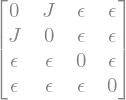

In [12]:
# building flip/flop hamiltonian
H = sp.Matrix([[0, J, epsilon, epsilon],
               [J, 0, epsilon, epsilon],
               [epsilon, epsilon, 0, epsilon],
               [epsilon, epsilon, epsilon, 0]])

H

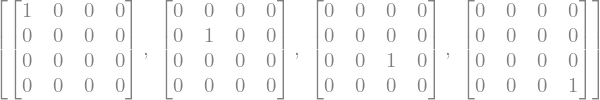

In [10]:
# building lindblad jump operators
L_operators = [sp.Matrix(N,N, lambda i,j: 1 if i==k and j==k else 0) for k in range(N)]

L_operators

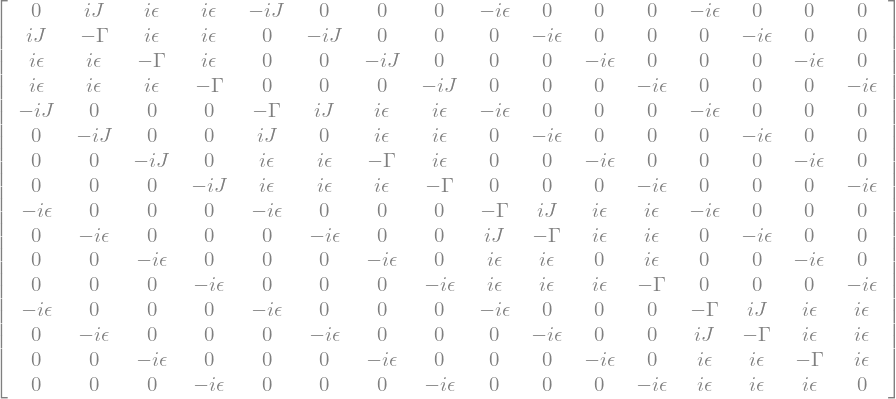

In [13]:
# constructing lindbladian
L, rho = lindbladian(N, output=False, degenerate=True, H=H, L_operators=L_operators)

# setting all dephasing constants to the same constant gamma
L = L.subs({sp.Symbol(f"Gamma_{i}", real=True, nonnegative=True): gamma for i in range(N)}).applyfunc(sp.factor)

L

In [14]:
mathematica_code(L).replace("Gamma","Γ").replace("epsilon", "ϵ")

'{{0, I*J, I*ϵ, I*ϵ, -I*J, 0, 0, 0, -I*ϵ, 0, 0, 0, -I*ϵ, 0, 0, 0}, {I*J, -Γ, I*ϵ, I*ϵ, 0, -I*J, 0, 0, 0, -I*ϵ, 0, 0, 0, -I*ϵ, 0, 0}, {I*ϵ, I*ϵ, -Γ, I*ϵ, 0, 0, -I*J, 0, 0, 0, -I*ϵ, 0, 0, 0, -I*ϵ, 0}, {I*ϵ, I*ϵ, I*ϵ, -Γ, 0, 0, 0, -I*J, 0, 0, 0, -I*ϵ, 0, 0, 0, -I*ϵ}, {-I*J, 0, 0, 0, -Γ, I*J, I*ϵ, I*ϵ, -I*ϵ, 0, 0, 0, -I*ϵ, 0, 0, 0}, {0, -I*J, 0, 0, I*J, 0, I*ϵ, I*ϵ, 0, -I*ϵ, 0, 0, 0, -I*ϵ, 0, 0}, {0, 0, -I*J, 0, I*ϵ, I*ϵ, -Γ, I*ϵ, 0, 0, -I*ϵ, 0, 0, 0, -I*ϵ, 0}, {0, 0, 0, -I*J, I*ϵ, I*ϵ, I*ϵ, -Γ, 0, 0, 0, -I*ϵ, 0, 0, 0, -I*ϵ}, {-I*ϵ, 0, 0, 0, -I*ϵ, 0, 0, 0, -Γ, I*J, I*ϵ, I*ϵ, -I*ϵ, 0, 0, 0}, {0, -I*ϵ, 0, 0, 0, -I*ϵ, 0, 0, I*J, -Γ, I*ϵ, I*ϵ, 0, -I*ϵ, 0, 0}, {0, 0, -I*ϵ, 0, 0, 0, -I*ϵ, 0, I*ϵ, I*ϵ, 0, I*ϵ, 0, 0, -I*ϵ, 0}, {0, 0, 0, -I*ϵ, 0, 0, 0, -I*ϵ, I*ϵ, I*ϵ, I*ϵ, -Γ, 0, 0, 0, -I*ϵ}, {-I*ϵ, 0, 0, 0, -I*ϵ, 0, 0, 0, -I*ϵ, 0, 0, 0, -Γ, I*J, I*ϵ, I*ϵ}, {0, -I*ϵ, 0, 0, 0, -I*ϵ, 0, 0, 0, -I*ϵ, 0, 0, I*J, -Γ, I*ϵ, I*ϵ}, {0, 0, -I*ϵ, 0, 0, 0, -I*ϵ, 0, 0, 0, -I*ϵ, 0, I*ϵ, I*ϵ, -Γ, I*ϵ}, {0, 0, 0, -

I copied the above lindbladian matrix into mathematica notebook [3.4.1]. This mathematica notebook computes the eigenvalues numerically as a function of epsilon and stores the eigenvalues in .dat files, which I've uploaded to jupyterhub. The code below plots these eigenvalues...

# computed evals numerically

/opt/conda/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/conda/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


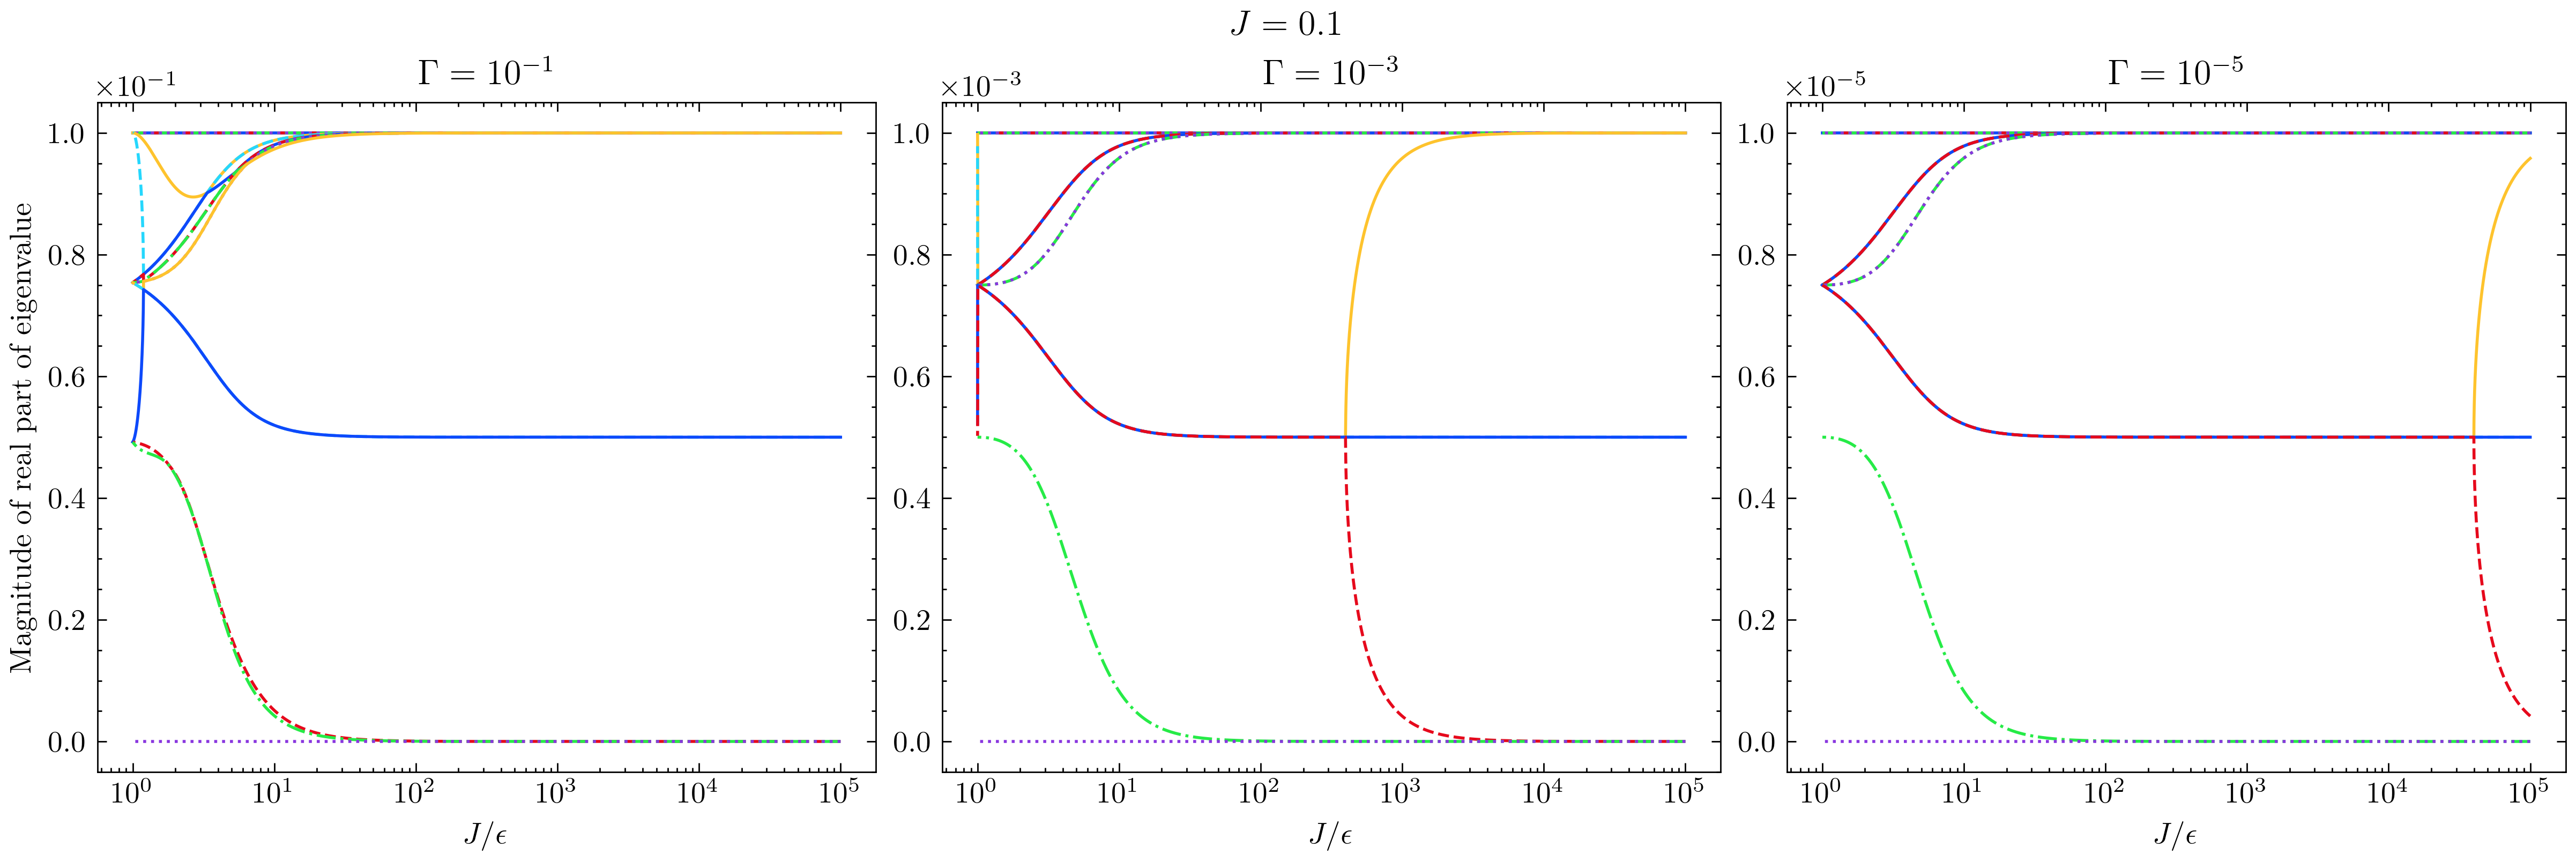

In [15]:
J_val = 0.1


datas = [
    np.loadtxt("gamma=1e-1; J=0.1.dat", dtype=np.complex128),
    np.loadtxt("gamma=1e-3; J=0.1.dat", dtype=np.complex128),
    np.loadtxt("gamma=1e-5; J=0.1.dat", dtype=np.complex128),
]
gammas = [
    1e-1,
    1e-3,
    1e-5,
]



fig, axs = plt.subplots(1,3, figsize=(12, 4), layout='constrained')
plt.style.use(['science', 'high-vis'])



        
for col, data in enumerate(datas):
    eps = data[:, 0]
    evals = data[:, 1:]
    
    for i in range(evals.shape[1]//2):
        axs[col].plot(J_val/eps,
                       np.abs(evals[:, 2*i]),
                        label=f"{i+1}",
                        #linewidth=2.75*0.95**i,
                        #alpha=1*0.9**i
                     )

    #axs[col].legend(title='Eigenvalue No.:', title_fontsize=12, fontsize=9, ncol=3, loc=(0.3, 0.2)) # plotting legend
    axs[col].set_xscale('log') # setting log scale for x axis
    axs[col].set_xlabel(r"$J / \epsilon$") # labelling x axis
    #axs[col].invert_xaxis() # inverting x axis
    axs[col].ticklabel_format(axis='y', style='sci', scilimits=(0, 0)) # using sci notation for y axis
    #axs[row][col].set_yscale('log') # setting log scale for y axis
    #axs[col].set_ylim([-1*gamma_val*0.2, gamma_val*1.2]) # forcing bounds of y axis (so that large magnitudes don't blow up the plot)
    axs[col].set_title(fr'$\Gamma=10^{{{int(np.log10(gammas[col]))}}}$')




axs[0].set_ylabel('Magnitude of real part of eigenvalue')  # labelling y axis
fig.suptitle(fr'$J={J_val}$')      
fig.savefig("splitting.pdf")


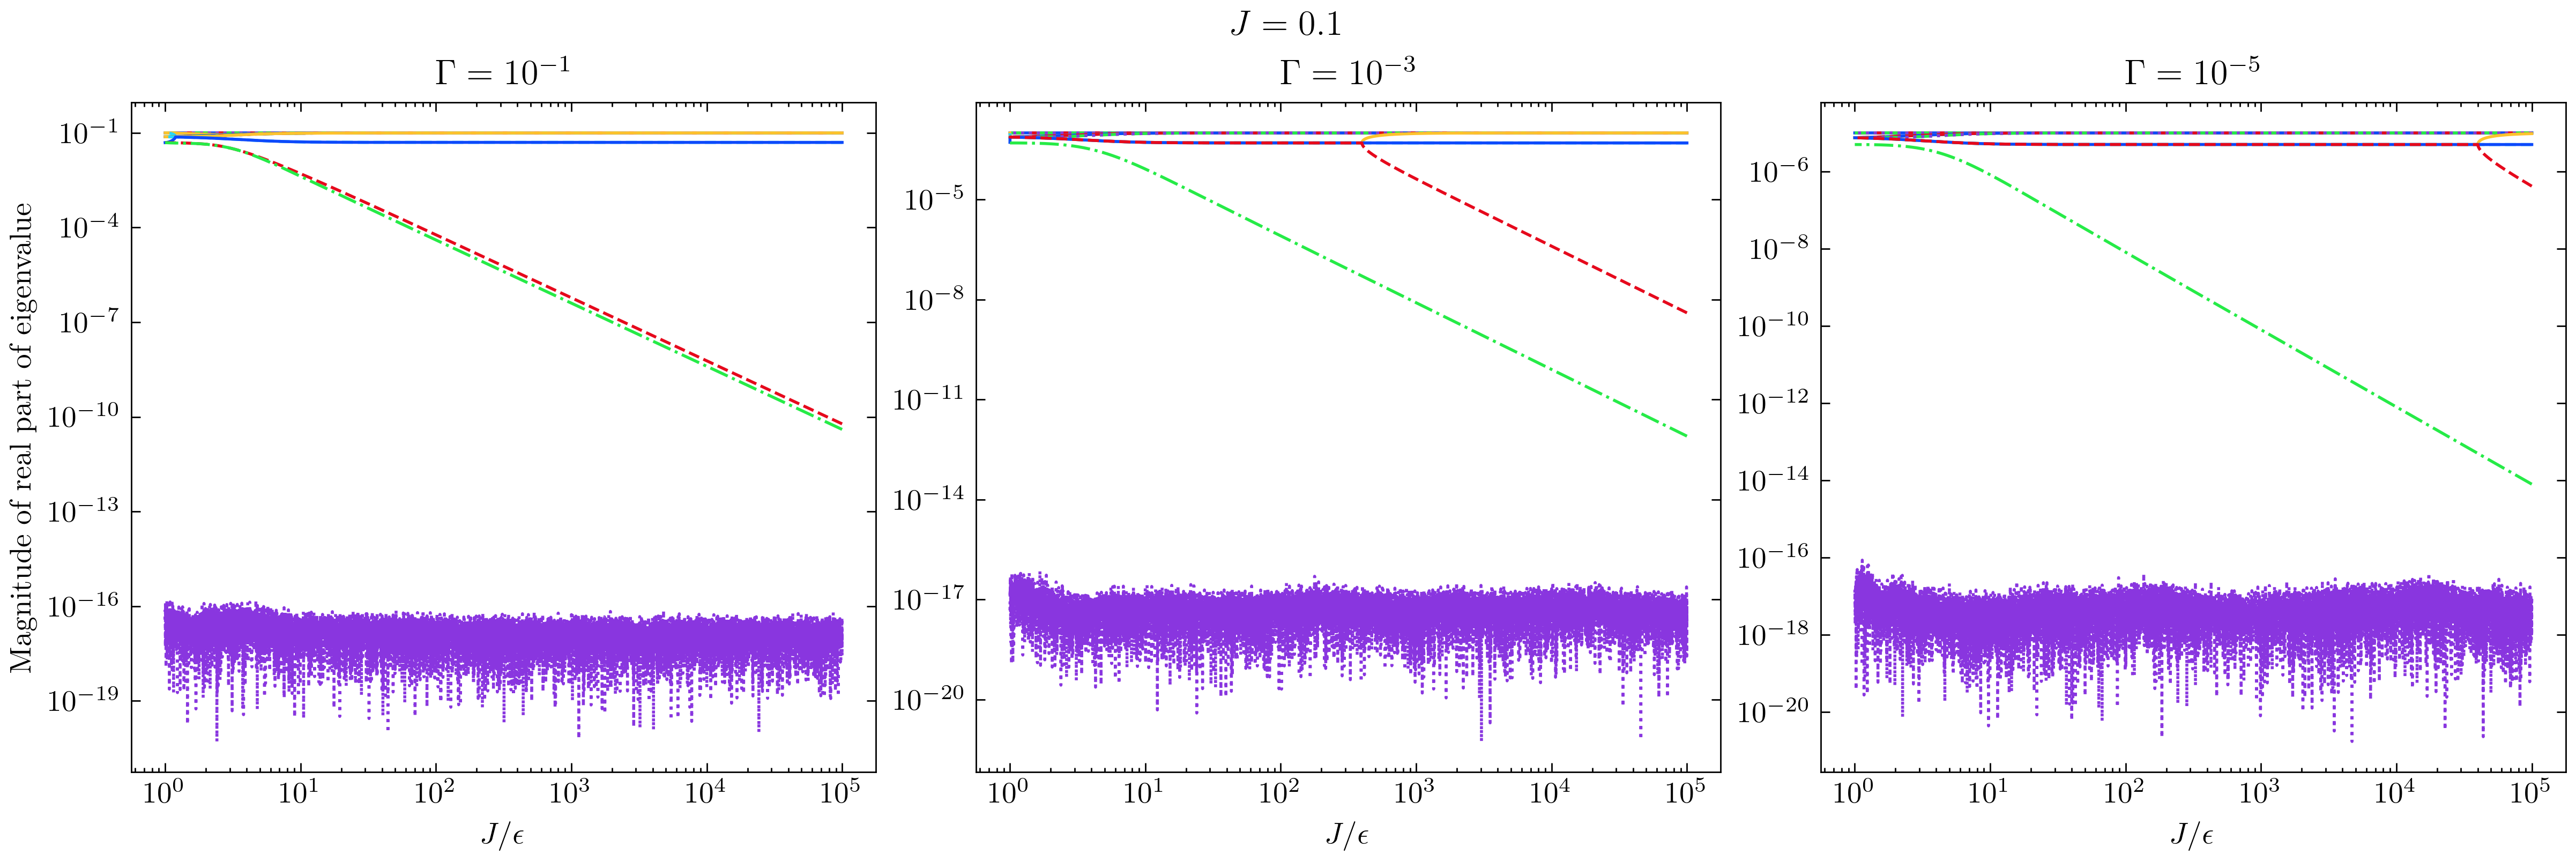

In [17]:
J_val = 0.1


datas = [
    np.loadtxt("gamma=1e-1; J=0.1.dat", dtype=np.complex128),
    np.loadtxt("gamma=1e-3; J=0.1.dat", dtype=np.complex128),
    np.loadtxt("gamma=1e-5; J=0.1.dat", dtype=np.complex128),
]
gammas = [
    1e-1,
    1e-3,
    1e-5,
]



fig, axs = plt.subplots(1,3, figsize=(12, 4), layout='constrained')
plt.style.use(['science', 'high-vis'])




        
for col, data in enumerate(datas):
    eps = data[:, 0]
    evals = data[:, 1:]
    
    for i in range(evals.shape[1]//2):
        axs[col].plot(J_val/eps,
                       np.abs(evals[:, 2*i]),
                        label=f"{i+1}",
                        #linewidth=2.75*0.95**i,
                        #alpha=1*0.9**i
                     )

    #axs[col].legend(title='Eigenvalue No.:', title_fontsize=12, fontsize=9, ncol=3, loc=(0.3, 0.2)) # plotting legend
    axs[col].set_xscale('log') # setting log scale for x axis
    axs[col].set_xlabel(r"$J / \epsilon$") # labelling x axis
    #axs[col].invert_xaxis() # inverting x axis
    axs[col].ticklabel_format(axis='y', style='sci', scilimits=(0, 0)) # using sci notation for y axis
    axs[col].set_yscale('log') # setting log scale for y axis
    #axs[col].set_ylim([-1*gamma_val*0.2, gamma_val*1.2]) # forcing bounds of y axis (so that large magnitudes don't blow up the plot)
    axs[col].set_title(fr'$\Gamma=10^{{{int(np.log10(gammas[col]))}}}$')




axs[0].set_ylabel('Magnitude of real part of eigenvalue')  # labelling y axis
fig.suptitle(fr'$J={J_val}$')      
fig.savefig("splitting log.pdf")


# eigenvalues analytically approximated $O(\epsilon^3)$

In [20]:
evals_string = '''
{0, -\[CapitalGamma], -\[CapitalGamma], -\[CapitalGamma] + (Sqrt[-J]*(-J + \[Epsilon]))/Sqrt[J], 
 -\[CapitalGamma] + (Sqrt[-J]*(J - \[Epsilon]))/Sqrt[J], (-8*\[CapitalGamma]*\[Epsilon]^2)/(J^2 + \[CapitalGamma]^2), 
 (-I)*(J - I*\[CapitalGamma] - \[Epsilon] + (4*(2*J - I*\[CapitalGamma])*\[Epsilon]^2)/(J*(J - I*\[CapitalGamma]))), 
 I*(J + I*\[CapitalGamma] - \[Epsilon] + (4*(2*J + I*\[CapitalGamma])*\[Epsilon]^2)/(J*(J + I*\[CapitalGamma]))), 
 (-I)*J - \[CapitalGamma] - I*\[Epsilon] + (2*((6*I)*J + \[CapitalGamma])*\[Epsilon]^2)/(J*(3*J + I*\[CapitalGamma])), 
 I*J - \[CapitalGamma] + I*\[Epsilon] + (2*((-6*I)*J + \[CapitalGamma])*\[Epsilon]^2)/(J*(3*J - I*\[CapitalGamma])), 
 (-\[CapitalGamma] - Sqrt[-16*J^2 + \[CapitalGamma]^2] + (8*(24*J^2 + \[CapitalGamma]*(-\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2]))*
     \[Epsilon]^2)/(\[CapitalGamma]^2*(\[CapitalGamma] - Sqrt[-16*J^2 + \[CapitalGamma]^2]) + 
     2*J^2*(-8*\[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2])))/2, 
 (48*J^4 - 4*\[CapitalGamma]*(\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2])*\[Epsilon]^2 + 
   J^2*(-3*\[CapitalGamma]^2 - 5*\[CapitalGamma]*Sqrt[-16*J^2 + \[CapitalGamma]^2] + 96*\[Epsilon]^2))/
  (\[CapitalGamma]^2*(\[CapitalGamma] + Sqrt[-16*J^2 + \[CapitalGamma]^2]) - 2*J^2*(8*\[CapitalGamma] + 3*Sqrt[-16*J^2 + \[CapitalGamma]^2])), 
 -\[CapitalGamma] + (4*\[Epsilon]^2)/\[CapitalGamma], (-4*(J^2 + 2*\[CapitalGamma]^2)*\[Epsilon]^2)/(\[CapitalGamma]*(J^2 + \[CapitalGamma]^2)), 
 (-I)*(J - I*\[CapitalGamma] + \[Epsilon] + (2*(2*J - I*\[CapitalGamma])*\[Epsilon]^2)/(J*(J - I*\[CapitalGamma]))), 
 I*(J + I*\[CapitalGamma] + \[Epsilon] + (2*(2*J + I*\[CapitalGamma])*\[Epsilon]^2)/(J*(J + I*\[CapitalGamma])))}
'''

<>:2: SyntaxWarning: invalid escape sequence '\['
<>:2: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_402/65085129.py:2: SyntaxWarning: invalid escape sequence '\['
  {0, -\[CapitalGamma], -\[CapitalGamma], -\[CapitalGamma] + (Sqrt[-J]*(-J + \[Epsilon]))/Sqrt[J],


++++++++++++++++++++++++++++++


++++++++++++++++++++++++++++++


++++++++++++++++++++++++++++++


++++++++++++++++++++++++++++++


++++++++++++++++++++++++++++++


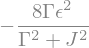

++++++++++++++++++++++++++++++


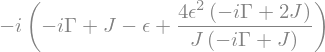

++++++++++++++++++++++++++++++


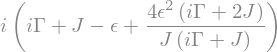

++++++++++++++++++++++++++++++


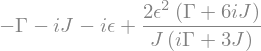

++++++++++++++++++++++++++++++


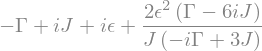

++++++++++++++++++++++++++++++


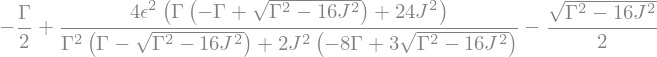

++++++++++++++++++++++++++++++


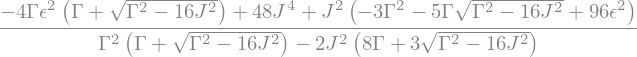

++++++++++++++++++++++++++++++


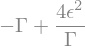

++++++++++++++++++++++++++++++


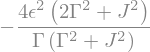

++++++++++++++++++++++++++++++


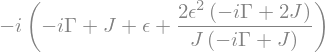

++++++++++++++++++++++++++++++


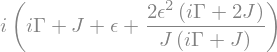

++++++++++++++++++++++++++++++


In [23]:
evals_approx = list(parse_mathematica(evals_string.replace(r"\[CapitalGamma]", "Gamma").replace(r"\[Epsilon]", "epsilon")))

evals_approx = [i.subs({sp.Symbol("Gamma"): gamma, sp.Symbol("epsilon"): epsilon, sp.Symbol("J"): J}) for i in evals_approx]

for i in evals_approx:
    display(i)
    print("++++++++++++++++++++++++++++++")

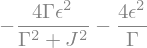

In [26]:
evals_approx[-3].apart(gamma)